# Jav: Initial EDA for GTFS data

### i. **Libraries**

In [23]:
# import libraries
import pandas as pd
import numpy as np
import gtfs_kit as gk
import geopandas as gp
from gtfs_kit import cleaners  # for cleaning functions
from gtfs_kit import miscellany  # for quality assessment
import matplotlib.pyplot as plt
import folium  # for interactive maps
from gtfs_kit import routes  # for route-specific functions
from IPython.display import display

In [24]:
# import GTFS feed data
feed_path = '/home/dataopske/Desktop/jav/data/raw/digitalmatatu/GTFS_FEED_2019.zip'
feed = gk.read_feed(feed_path,dist_units='km')

### ii. **GTFS: Data Description**

**What is GTFS?**
>GTFS (General Transit Feed Specification) is an open, standardized format developed by Google in 2005 for sharing public transit data, including schedules, routes, and geographic information. It's widely used by transit agencies, apps (e.g., Google Maps, Transit), and developers to model bus, rail, ferry, and other services. A GTFS feed is typically a ZIP file containing CSV tables that interconnect via unique IDs, allowing queries like "find all stops on a route" or "get arrival times for a trip."

**Digital Matatus Dataset**

The Digital Matatus project is an open-source initiative by MIT and local partners that mapped Nairobi's informal matatu (minibus) transit system, collecting data on 135 routes, 4,000+ stops, and schedules. Released as GTFS in 2019, it powers mobile apps, transit maps, and urban mobility research for Kenya's busiest public transport network.

**Source & Download**: [Digital Matatus Official Site](https://digitalmatatus.com/) (GTFS feed available via [OpenAfrica](https://bulk.openafrica.net/id/dataset/gtfs-data-on-public-transport-matatu-routes)).

GTFS feed contains the following tables
1. agency.txt
2. calendar.txt
3. calendar_dates.txt
4. feed_info.txt
5. frequencies.txt
6. routes.txt
7. shapes.txt
8. stop_times.txt
9. stops.txt
10. trips.txt

### iii. **Validation and Cleaning**

#### a. Validate

This section performs a **data quality assessment and cleanup** of the GTFS feed to ensure it’s ready for analysis.

* `miscellany.assess_quality(feed)` checks for issues such as **missing shapes**, **unused stops**, or **incomplete trip data**, returning a summary table of quality indicators.
* `cleaners.clean(feed)` then **fixes and standardizes** the data — cleaning IDs, formatting times, correcting route names, and removing invalid (“zombie”) records.
* Finally, a quick health check prints the **feed’s validity period** and basic statistics like the total number of routes, stops, and trips after cleaning.


In [25]:
# assess quality (like validation): Checks for issues like missing shapes or unused stops
quality_results = miscellany.assess_quality(feed)
print("Feed Quality Indicators:")
print(quality_results)  # dataFrame with metrics like 'num_routes', 'num_trips_missing_shapes', etc.

# clean the feed: Applies ID cleaning, time formatting, route name fixes, and drops zombies
feed = cleaners.clean(feed)  # comprehensive: Includes drop_zombies internally

# quick health check (post-cleaning)
print(f"\nFeed validity period: {feed.feed_info.feed_start_date} to {feed.feed_info.feed_end_date}")
print(f"Number of routes: {len(feed.routes)}")
print(f"Number of stops: {len(feed.stops)}")
print(f"Number of trips: {len(feed.trips)}")

Feed Quality Indicators:
                             indicator                    value
0     num_route_short_names_duplicated                        0
1    frac_route_short_names_duplicated                      0.0
2          num_stop_time_dists_missing                     7533
3         frac_stop_time_dists_missing                        1
4            num_direction_ids_missing                        0
5           frac_direction_ids_missing                      0.0
6             num_trips_missing_shapes                        0
7            frac_trips_missing_shapes                      0.0
8          num_departure_times_missing                        0
9         frac_departure_times_missing                      0.0
10   num_first_departure_times_missing                        0
11  frac_first_departure_times_missing                      0.0
12    num_last_departure_times_missing                        0
13   frac_last_departure_times_missing                      0.0
14             

The quality check shows that the GTFS feed is **mostly clean**, with no duplicate route names or missing shapes. However, **all stop-time distances are missing** (`frac_stop_time_dists_missing = 1`), meaning distances between stops weren’t provided. Despite this, the feed is **“probably fixable.”**

After cleaning, the feed covers **March 2, 2012 – December 31, 2020**, with **136 routes**, **4,284 stops**, and **272 trips**.


#### b. Metadata

In [26]:
# get available tables
tables = [attr for attr in dir(feed) if hasattr(getattr(feed, attr), 'head')]
for table in tables:
    df = getattr(feed, table)
    if df is not None:
        print(f"{table}: {len(df)} rows, {len(df.columns)} columns")
df.head()

agency: 1 rows, 6 columns
calendar: 1 rows, 10 columns
calendar_dates: 4 rows, 3 columns
feed_info: 1 rows, 5 columns
frequencies: 792 rows, 4 columns
routes: 136 rows, 5 columns
shapes: 36483 rows, 4 columns
stop_times: 7533 rows, 5 columns
stops: 4284 rows, 6 columns
trips: 272 rows, 6 columns


,route_id,service_id,trip_id,trip_headsign,direction_id,shape_id
0,10000107D11,DAILY,1107D110,Ruaka,0,1107D110
1,10000107D11,DAILY,1107D111,Ruiru,1,1107D111
2,10000114011,DAILY,10114110,Ngara,0,10114110
3,10000114011,DAILY,10114111,Limuru,1,10114111
4,10000116011,DAILY,10116110,Koja,0,10116110


### iv. **Descriptive Analysis**

#### a. Agency

- basic info on the transit agency(ies) providing service, e.g., agency name, URL, timezone, contact phone. (Usually 1+ rows, one per agency.)

In [27]:
agency = feed.agency
agency.head()

,agency_id,agency_name,agency_url,agency_timezone,agency_lang,agency_phone
0,UON,Approved SACCOs - University of Nairobi C4D La...,http://www.digitalmatatus.com,Africa/Nairobi,en,020 - 2729200


#### b. Calendar

- Defines service patterns for groups of trips by day-of-week (e.g., monday=1, tuesday=1 for weekdays), plus start/end dates. Used for regularly scheduled services.

In [28]:
cal = feed.calendar
cal.head()

,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date
0,DAILY,1,1,1,1,1,1,1,20190101,20201231


In [29]:
cal.shape

(1, 10)

#### c. Calendar dates

- Exceptions to calendar.txt, e.g., added/removed service dates for holidays or events (service_id, date, exception_type=1 for added, 2 for removed).

In [30]:
cal_dates = feed.calendar_dates
cal_dates

,service_id,date,exception_type
0,DAILY,20191020,1
1,DAILY,20191212,1
2,DAILY,20201020,1
3,DAILY,20201212,1


In [31]:
cal_dates.shape

(4, 3)

#### d. Feed info

- Metadata about the entire feed, e.g., feed publisher, version, start/end validity dates, contact email. (Typically 1 row.)

In [32]:
info = feed.feed_info
info.head()

,feed_publisher_name,feed_publisher_url,feed_lang,feed_start_date,feed_end_date
0,TRAINING,http://www.digitalmatatus.com/,en,20120302,20201231


#### e. Frequencies

- Headways (time intervals) for high-frequency trips without fixed schedules, e.g., every 10 minutes from 7 AM (trip_id, start_time, end_time, headway_secs).

In [33]:
freqs = feed.frequencies
freqs.head()

,trip_id,start_time,end_time,headway_secs
0,10106110,06:00:00,09:00:00,300
1,10106110,09:00:00,15:00:00,900
2,10106110,15:00:00,21:00:00,300
3,10106111,06:00:00,09:00:00,300
4,10106111,09:00:00,15:00:00,900


In [34]:
freqs.shape

(792, 4)

#### f. Routes

- Details on routes, e.g., route_id, short/long names, type (bus=3, rail=2), agency_id, color. Acts as a high-level grouping for trips.

In [35]:
routes = feed.routes
routes.head(5)

,route_id,agency_id,route_short_name,route_long_name,route_type
0,10000107D11,UON,107D,Ruaka-Ruiru,3
1,10000114011,UON,114R,Ngara-Rwaka-Ndenderu-Limuru,3
2,10000116011,UON,116,Koja-Ngara-Banana-Limuru,3
3,10100011A11,UON,11A,Odeon-Aga Khan-Highridge,3
4,10200010811,UON,108,UN-New Muthaiga-Gachie-Gichagi,3


In [36]:
routes

,route_id,agency_id,route_short_name,route_long_name,route_type
0,10000107D11,UON,107D,Ruaka-Ruiru,3
1,10000114011,UON,114R,Ngara-Rwaka-Ndenderu-Limuru,3
2,10000116011,UON,116,Koja-Ngara-Banana-Limuru,3
3,10100011A11,UON,11A,Odeon-Aga Khan-Highridge,3
4,10200010811,UON,108,UN-New Muthaiga-Gachie-Gichagi,3
...,...,...,...,...,...
131,80101048B11,UON,48B,Odeon-Chiromo-Westlands Bypass-Methodist Guest...,3
132,80200004811,UON,48K,Westlands-ABC Place-Lavington-Kawangware,3
133,80200048C11,UON,48C,Odeon-Chiromo-Westlands-ByPass-Yaya,3
134,80400003011,UON,30,Odeon-Westlands-Kangemi-Uthiru,3


In [37]:
# number of routes
routes_no = routes['route_id'].nunique()
print(f'There are {routes_no} different routes in this dataset.')

There are 136 different routes in this dataset.


In [57]:
from gtfs_kit import routes

# Get all short names of routes
all_short_names = feed.routes['route_short_name'].dropna().tolist()

# Plot routes using gtfs_kit (returns a Folium map)
m = routes.map_routes(feed, route_short_names=all_short_names)

# --- Lock zoom and restrict panning ---
m.options['minZoom'] = 11       #  can't zoom out below 11
m.options['maxZoom'] = 18       # can zoom in for more detail
m.options['scrollWheelZoom'] = False
m.options['dragging'] = True    # set to False to freeze map

# --- Restrict panning to feed area ---
bounds = [
    [feed.stops['stop_lat'].min(), feed.stops['stop_lon'].min()],
    [feed.stops['stop_lat'].max(), feed.stops['stop_lon'].max()]
]
m.fit_bounds(bounds)
m.options['maxBounds'] = bounds

# --- Change basemap to CartoDB Positron ---
folium.TileLayer('CartoDB Positron', name='Positron', show=True).add_to(m)

m

#### g. Shapes

Geographic paths for routes as sequences of points (shape_id, lat, lon, sequence). Optional; used for mapping curved routes.

In [40]:
shape = feed.shapes
shape.head()

,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence
0,10106110,-1.173842,36.758779,1
1,10106110,-1.174523,36.759025,2
2,10106110,-1.175076,36.759267,3
3,10106110,-1.175821,36.759535,4
4,10106110,-1.176998,36.759982,5


In [41]:
shape.shape

(36483, 4)

#### h. Stops

- Stop locations: stop_id, name, lat/lon, platform code, parent station (for grouped stops like platforms). Forms the network of points.

In [42]:
stops = feed.stops
stops.head(5)

,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station
0,0001RLW,Railways,-1.290884,36.828242,0,NaN
1,0002KOJ,Koja,-1.281230,36.822596,1,NaN
2,0003NGR,Ngara,-1.274395,36.823806,1,NaN
3,0004ODN,Odeon,-1.282769,36.825032,1,NaN
4,0005AMB,Kencom/Ambassadeur,-1.285963,36.826048,1,NaN


In [43]:
stops.shape

(4284, 6)

In [44]:
print(f'There are {stops['stop_id'].nunique()} stops in this dataset')

There are 4284 stops in this dataset


In [45]:
stops['stop_name'].value_counts()

stop_name
Tuskys                       23
Car Wash                     22
Naivas                       21
Kwa Chief                    19
Equity                       17
                             ..
Stima Sacco                   1
Mothers Mercys/GD             1
Mifereji/God's Ability        1
Donholm Interchange/Stage     1
Kwa D.O                       1
Name: count, Length: 2474, dtype: Int64

In [46]:
stops['stop_name'].nunique()

2474

In [48]:
print(f"The avg stops per route is: {feed.stops.shape[0] / len(feed.routes):.1f}")

The avg stops per route is: 31.5


- Map of stops

In [51]:
import folium

# Define map center
center_lat = feed.stops['stop_lat'].mean()
center_lon = feed.stops['stop_lon'].mean()

# Create base map (no default tiles so you can add your own)
m = folium.Map(
    location=[center_lat, center_lon],
    tiles=None,
    zoom_start=11,
    min_zoom=11,
    max_zoom=18,
    scrollWheelZoom=False,
    dragging=True
)

# Add Positron as default (show=True)
folium.TileLayer('CartoDB Positron', name='Positron', control=True, show=True).add_to(m)
folium.TileLayer('OpenStreetMap', name='OpenStreetMap', control=True, show=False).add_to(m)
folium.TileLayer('CartoDB Dark_Matter', name='Dark Matter', control=True, show=False).add_to(m)

# Restrict panning to feed area
bounds = [
    [feed.stops['stop_lat'].min(), feed.stops['stop_lon'].min()],
    [feed.stops['stop_lat'].max(), feed.stops['stop_lon'].max()]
]
m.fit_bounds(bounds)
m.options['maxBounds'] = bounds

# Add stops layer
stops_group = folium.FeatureGroup(name="Stops", show=True)
for _, row in feed.stops.iterrows():
    folium.CircleMarker(
        location=[row.stop_lat, row.stop_lon],
        radius=2,
        color="blue",
        fill=True,
        fill_opacity=0.6
    ).add_to(stops_group)
stops_group.add_to(m)

# Layer control
folium.LayerControl(collapsed=False).add_to(m)

m

- sequences of `stops` for one route

In [53]:
# Pick a route_id
sample_route_id = feed.routes.route_id.iloc[0]
route_trips = feed.trips[feed.trips.route_id == sample_route_id].trip_id.unique()[:5]  # Sample trips
path = feed.stop_times[feed.stop_times.trip_id.isin(route_trips)].merge(
    feed.stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']], on='stop_id'
).sort_values(['trip_id', 'stop_sequence'])
print(f'The route has {path.stop_id.nunique()} stops.')
path.head(20)  # Sequence of stops with times/locations

The route has 68 stops.


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_name,stop_lat,stop_lon
0,1107D110,06:00:00,06:00:20,0213MRY,1,Ruiru,-1.147669,36.959317
1,1107D110,06:02:39,06:02:59,0100OOA,2,Kwa Soko,-1.149789,36.948829
2,1107D110,06:03:26,06:03:46,0100AWA,3,Wataalam,-1.149612,36.947408
3,1107D110,06:04:18,06:04:38,0100TPS,4,Post,-1.149687,36.945525
4,1107D110,06:05:25,06:05:45,0100OTN,5,Hilton,-1.150637,36.942590
5,1107D110,06:06:57,06:07:17,0110LHL,6,Full Gospel Church,-1.151018,36.937462
6,1107D110,06:08:43,06:09:03,0110AOH,7,Mama Shop,-1.151753,36.931196
7,1107D110,06:09:33,06:09:53,0110ISR,8,Ruiru Prisons,-1.151871,36.929525
8,1107D110,06:11:59,06:12:19,0100RJI,9,Ruiru Road Junction,-1.152105,36.919942
9,1107D110,06:12:40,06:13:00,0100JO.,10,O.J,-1.152971,36.920232


- sequences of `stops` visualised for one route

In [55]:
import folium

# --- Center map around the first stop ---
center_lat = path['stop_lat'].mean()
center_lon = path['stop_lon'].mean()

# --- Create base map with zoom restrictions ---
m = folium.Map(
    location=[center_lat, center_lon],
    tiles='CartoDB Positron',
    zoom_start=12,
    min_zoom=12,      # can't zoom out below 12
    max_zoom=18,      # can zoom in for more detail
    scrollWheelZoom=False,
    dragging=True     # set to False to fully disable panning
)

# --- Restrict panning to the route area ---
bounds = [
    [path['stop_lat'].min(), path['stop_lon'].min()],
    [path['stop_lat'].max(), path['stop_lon'].max()]
]
m.fit_bounds(bounds)
m.options['maxBounds'] = bounds

# --- Plot each trip path ---
for trip_id, trip_data in path.groupby('trip_id'):
    trip_coords = trip_data[['stop_lat', 'stop_lon']].values.tolist()
    folium.PolyLine(
        trip_coords,
        color='blue',
        weight=3,
        opacity=0.7,
        tooltip=f"Trip ID: {trip_id}"
    ).add_to(m)
    
    # --- Add stop markers ---
    for _, row in trip_data.iterrows():
        folium.CircleMarker(
            location=[row['stop_lat'], row['stop_lon']],
            radius=4,
            color='red',
            fill=True,
            fill_opacity=0.9,
            tooltip=row['stop_name']
        ).add_to(m)

# --- Display map ---
m

#### i. Stop times

- Timetables for trips: arrival/departure times, stop sequences, distances (trip_id, stop_id, arrival_time, departure_time, stop_sequence). Core table for schedules.

In [ ]:
stop_time = feed.stop_times
stop_time.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence
0,10106110,06:00:00,06:00:20,0110BAA,1
1,10106110,06:00:34,06:00:54,0110BNI,2
2,10106110,06:01:10,06:01:30,0110UMK,3
3,10106110,06:01:49,06:02:09,0110AEA,4
4,10106110,06:02:45,06:03:05,0100MOM,5


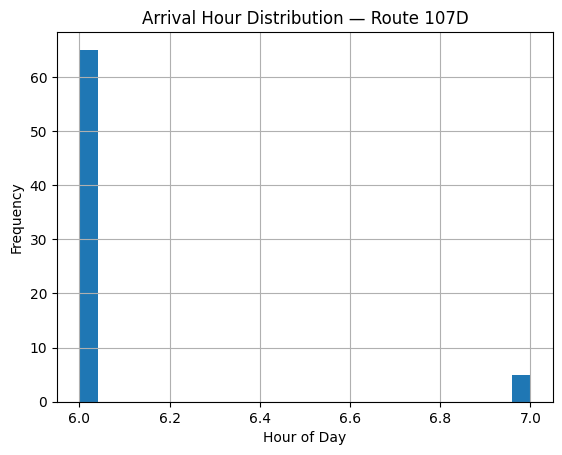

In [ ]:
# Select one route
sample_route = feed.routes.route_short_name.iloc[0]

# Filter trips for that route
route_trips = feed.trips[
    feed.trips.route_id == feed.routes[feed.routes.route_short_name == sample_route].route_id.iloc[0]
]

# Get stop_times for those trips
sample_stop_times = feed.stop_times[
    feed.stop_times.trip_id.isin(route_trips.trip_id)
].copy()

# Extract hour from arrival_time safely
sample_stop_times['arrival_hour'] = pd.to_datetime(
    sample_stop_times['arrival_time'],
    format='%H:%M:%S',
    errors='coerce'
).dt.hour

# Plot histogram
sample_stop_times['arrival_hour'].hist(bins=24)
plt.title(f"Arrival Hour Distribution — Route {sample_route}")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")
plt.show()

#### j. Trips

- Individual vehicle runs: trip_id, route_id, service_id (links to calendar), headsign (destination), shape_id, wheelchair_accessible. Bridges routes to stop_times.

In [ ]:
trips = feed.trips
trips.head()

,route_id,service_id,trip_id,trip_headsign,direction_id,shape_id
0,10000107D11,DAILY,1107D110,Ruaka,0,1107D110
1,10000107D11,DAILY,1107D111,Ruiru,1,1107D111
2,10000114011,DAILY,10114110,Ngara,0,10114110
3,10000114011,DAILY,10114111,Limuru,1,10114111
4,10000116011,DAILY,10116110,Koja,0,10116110
